# Figure 4 plotting

Figure 4 is generated on the last cell

In [1]:
import sys
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import rcParams

from typing import List, Tuple, Sequence, Optional, Dict, Any, Union

import os, math, re, glob
import seaborn as sns

from math import pi
from collections import deque
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, peak_widths
from scipy.special import wofz
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

from ase import Atoms
from ase.io import read, write

from Final_Results_functions import *
import panel_fit as pf 

In [2]:
def true_vectorized_voigt(x, centers, sigmas, gammas, areas):
    x = np.asarray(x)
    x_reshaped = x.reshape(1, -1)
    centers_reshaped = np.asarray(centers).reshape(-1, 1)
    sigmas_reshaped  = np.asarray(sigmas).reshape(-1, 1)
    gammas_reshaped  = np.asarray(gammas).reshape(-1, 1)

    z = ((x_reshaped - centers_reshaped) + 1j * gammas_reshaped) / (sigmas_reshaped * np.sqrt(2.0))
    w_values = wofz(z)
    profiles = np.real(w_values) / (sigmas_reshaped * np.sqrt(2.0 * np.pi))
    return profiles * np.asarray(areas).reshape(-1, 1)

def batch_voigt_profiles(x, centers, widths, areas, gamma_fracs, min_width=1e-10):
    x = np.asarray(x)
    centers = np.asarray(centers, float)
    widths  = np.asarray(widths,  float)
    areas   = np.asarray(areas,   float)
    gamma_fracs = np.clip(np.asarray(gamma_fracs, float), 0.0, 1.0)

    n = len(centers)
    if n == 0:
        return np.zeros((0, len(x)))

    sqrt_2ln2 = np.sqrt(2.0 * np.log(2.0))
    widths = np.maximum(widths, min_width)

    sigma = np.empty(n, dtype=float)
    gamma = np.empty(n, dtype=float)

    is_gauss = gamma_fracs < 1e-8
    is_lor   = gamma_fracs > (1.0 - 1e-8)
    is_mix   = ~(is_gauss | is_lor)

    if np.any(is_gauss):
        sigma[is_gauss] = widths[is_gauss] / (2.0 * sqrt_2ln2)
        gamma[is_gauss] = 1e-15
    if np.any(is_lor):
        gamma[is_lor] = widths[is_lor] / 2.0
        sigma[is_lor] = 1e-15
    if np.any(is_mix):
        V = widths[is_mix]
        f = gamma_fracs[is_mix]
        L = f * V
        term = V - 0.5346 * L
        G_sq = np.maximum(0.0, term**2 - 0.2166 * L**2)
        G = np.sqrt(G_sq)
        sigma[is_mix] = G / (2.0 * sqrt_2ln2)
        gamma[is_mix] = L / 2.0

    sigma = np.maximum(sigma, 1e-15)
    gamma = np.maximum(gamma, 1e-15)

    return true_vectorized_voigt(x, centers, sigma, gamma, areas)

def voigt_profile(x, center, voigt_fwhm, area, lorentz_frac):
    return batch_voigt_profiles(
        x,
        centers=np.array([center]),
        widths=np.array([voigt_fwhm]),
        areas=np.array([area]),
        gamma_fracs=np.array([lorentz_frac]),
    )[0]

def multi_voigt_free_gamma(x, *flat_params):
    x = np.asarray(x)
    y = np.zeros_like(x, float)
    if len(flat_params) % 4 != 0:
        raise ValueError("params must be multiple of 4: (center,width,area,gamma_ratio) per peak")
    for i in range(0, len(flat_params), 4):
        c, w, A, r = flat_params[i:i+4]
        y += voigt_profile(x, c, w, A, r)
    return y

def build_initial_guesses_and_bounds(x, y, centers, rough_width=40.0,
                                     center_window=20.0, min_width=30.0, max_width=100.0,
                                     rough_gamma_ratio=0.0):
    p0, lb, ub = [], [], []
    ymax = np.nanmax(y)
    if (not np.isfinite(ymax)) or ymax <= 0:
        ymax = 1.0

    for c0 in centers:
        # center
        p0.append(float(c0)); lb.append(float(c0-center_window)); ub.append(float(c0+center_window))
        # width
        w0 = float(np.clip(rough_width, min_width, max_width))
        p0.append(w0); lb.append(float(min_width)); ub.append(float(max_width))
        # area 
        A0 = max(1e-12, ymax * w0)
        p0.append(A0); lb.append(0.0); ub.append(1e6*A0)
        # gamma ratio
        r0 = float(np.clip(rough_gamma_ratio, 0.0, 1.0))
        p0.append(r0); lb.append(0.0); ub.append(1.0)

    return np.array(p0, float), (np.array(lb, float), np.array(ub, float))


In [3]:
def plot_zoomed_region_panel_fit(ax, ds,
                                      x_min=1270.0, x_max=1700.0,
                                      rough_centers=(1320, 1370, 1485, 1556, 1606),
                                      peak_labels=("D1", "D2", "B", "L", "G"),
                                      show_std_band=True,
                                      data_color="C2"):

    wave_number = ds["wave_number"].values
    reduce_dims = [d for d in ds["spectra"].dims if d != "wave_number"]  # <- key detail

    diff = ds["predicted_difference"]
    diff_mean_all = diff.mean(dim=reduce_dims).values
    diff_std_all  = diff.std(dim=reduce_dims).values

    m = (wave_number >= x_min) & (wave_number <= x_max)
    x = wave_number[m]
    y = diff_mean_all[m]
    ystd = diff_std_all[m]

    # fit on the SAME mean curve
    p0, bounds = build_initial_guesses_and_bounds(x, y, centers=np.array(rough_centers, float))
    popt, _ = curve_fit(multi_voigt_free_gamma, x, y, p0=p0, bounds=bounds, maxfev=30000)
    yfit = multi_voigt_free_gamma(x, *popt)

    # components
    comps = []
    for i in range(len(popt)//4):
        c, w, A, r = popt[4*i:4*i+4]
        comps.append(voigt_profile(x, c, w, A, r))

    comp_colors = {"D1":"tab:blue",
                   "$D_1$":"tab:blue",
                   "D2":"tab:orange",
                   "$D2_a$":"tab:orange",
                   "$D2_b$":"tab:orange",
                   "$D2_c$":"tab:orange",
                   r"$D_{2a}$":"tab:orange",
                   r"$D_{2b}$":"tab:orange",
                   r"$D_{2c}$":"tab:orange",
                   "B":"tab:green",
                   "L":"tab:red",
                   "G":"tab:purple",
                     "G-like":"tab:purple"
                   }

    # ---- panel_fit DATA (mean +/- std) ----
    # ax.plot(x, y, lw=0, marker='.',color=data_color, label="Data")
    ax.plot(x, y, color=data_color, label="Data", alpha=0.75)
    if show_std_band:
        ax.fill_between(x, y-ystd, y+ystd, color=data_color, alpha=0.2, linewidth=0)

    # ---- overlay fit + components ----
    ax.plot(x, yfit, "--", lw=3.0, color="tab:red", label="Fit")

    for lab, comp in zip(peak_labels, comps):
        ax.plot(x, comp, "--", lw=1.8, color=comp_colors.get(lab, "k"), label=f"{lab} peak")
        xm = x[np.argmax(comp)]
        ym = np.max(comp)
        ax.text(xm, -0.03, lab, ha="center", va="bottom",fontsize=18)

    ax.set_xlim(x_min, x_max)
    # ax.set_ylim(-0.05,0.125)
    ax.set_ylabel("Intensity, a.u.")
    ax.set_xlabel(r"Raman shift, cm$^{-1}$")

    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.02))
    # ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2],
            frameon=False, fontsize=18, loc="best")

    return popt

In [4]:
def plot_peak_map(ax, all_xy, values, cell_poly, title,
                  top_color="tab:blue", marker_size=50,
                  vmin=0.0, vmax=1.0,
                  show_xlabel=False, show_ylabel=False,
                  draw_background=True):

    sc_bg = None
    if draw_background:
        cmap_gray = mcolors.LinearSegmentedColormap.from_list("gray01", ["white", "black"])
        sc_bg = ax.scatter(all_xy[:, 0], all_xy[:, 1], c=values, s=1,
                           cmap=cmap_gray, vmin=0.0, vmax=1.0,
                           edgecolors="none", zorder=0)

    cmap_col = mcolors.LinearSegmentedColormap.from_list("col", ["white", top_color])
    ax.scatter(all_xy[:, 0], all_xy[:, 1], c=values, s=marker_size,
               cmap=cmap_col, vmin=vmin, vmax=vmax,
               edgecolors=top_color, linewidths=0.2, zorder=2)

    ax.plot(cell_poly[:, 0], cell_poly[:, 1], "k--", lw=1.2, zorder=5)
    ax.set_aspect("equal", "box")
    ax.set_title(title)

    if show_xlabel:
        ax.set_xlabel(r"x, $\rm \AA{}$")
    else:
        ax.tick_params(labelbottom=False)

    if show_ylabel:
        ax.set_ylabel(r"y, $\rm \AA{}$")
    else:
        ax.tick_params(labelleft=False)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(15))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(3))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(15))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(3))
    return sc_bg

In [5]:
# --- Peak-atom values ---
L_values  = np.loadtxt('L_peak_atoms.dat')[:, 3]
B_values  = np.loadtxt('B_peak_atoms.dat')[:, 3]
G_values  = np.loadtxt('G_peak_atoms.dat')[:, 3]
D1_values = np.loadtxt('D1_peak_atoms.dat')[:, 3]
D2_values = np.loadtxt('D2_peak_atoms.dat')[:, 3]
D3_values = np.loadtxt('D3_peak_atoms.dat')[:, 3]
D4_values = np.loadtxt('D4_peak_atoms.dat')[:, 3]

# --- Geometry (BL positions + in-plane cell vectors) ---
pdb_file = "BL.pdb"
coords, cell = read_pdb_xy_cell(pdb_file) 

# --- Tiling settings ---
nrep_a = 3
nrep_b = 3

base_xy, a_vec, b_vec = build_base_xy(coords, cell)  
all_xy = tile_xy(base_xy, a_vec, b_vec, nrep_a, nrep_b)

n_tiles = (2*nrep_a + 1) * (2*nrep_b + 1)

all_B  = np.tile(B_values  / np.max(B_values),  n_tiles)
all_L  = np.tile(L_values  / np.max(L_values),  n_tiles)
all_G  = np.tile(G_values  / np.max(G_values),  n_tiles)

all_D1 = np.tile(D1_values / np.max(D1_values), n_tiles)
all_D2 = np.tile(D2_values / np.max(D2_values), n_tiles)
all_D3 = np.tile(D3_values / np.max(D3_values), n_tiles)
all_D4 = np.tile(D4_values / np.max(D4_values), n_tiles)

cell_poly = np.array([
    [0.0, 0.0],
    a_vec,
    a_vec + b_vec,
    b_vec,
    [0.0, 0.0],
])

In [6]:
ds_filepath = Path('unmixed_by_min70_highf_RUN3REC2_Buffer_20241011_1_11x11_pt1.nc')

try:
    ds = xr.open_dataset(ds_filepath, engine="netcdf4")
except Exception:
    ds = xr.open_dataset(ds_filepath, engine="h5netcdf")

ds = ds.load()
ds

<xarray.Dataset>
Dimensions:                        (X_0: 11, X_1: 11, wave_number: 1015)
Coordinates:
  * X_0                            (X_0) float64 2.032e+04 ... 2.033e+04
  * X_1                            (X_1) float64 -1.682e+04 ... -1.681e+04
  * wave_number                    (wave_number) float32 1.278e+03 ... 2.82e+03
Data variables:
    spectra                        (X_0, X_1, wave_number) float32 0.4856 ......
    masked_spectra                 (X_0, X_1, wave_number) float32 -1.0 ... -1.0
    mask                           (X_0, X_1, wave_number) bool False ... False
    predicted_spectra              (X_0, X_1, wave_number) float32 0.4692 ......
    predicted_difference           (X_0, X_1, wave_number) float32 0.01638 .....
    filtered_spectra               (X_0, X_1, wave_number) float32 0.4949 ......
    filtered_predicted_difference  (X_0, X_1, wave_number) float32 0.0121 ......

In [7]:
plt.rcParams.update({
    "font.size": 9,          # base font
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 8,
    "figure.titlesize": 11,
})

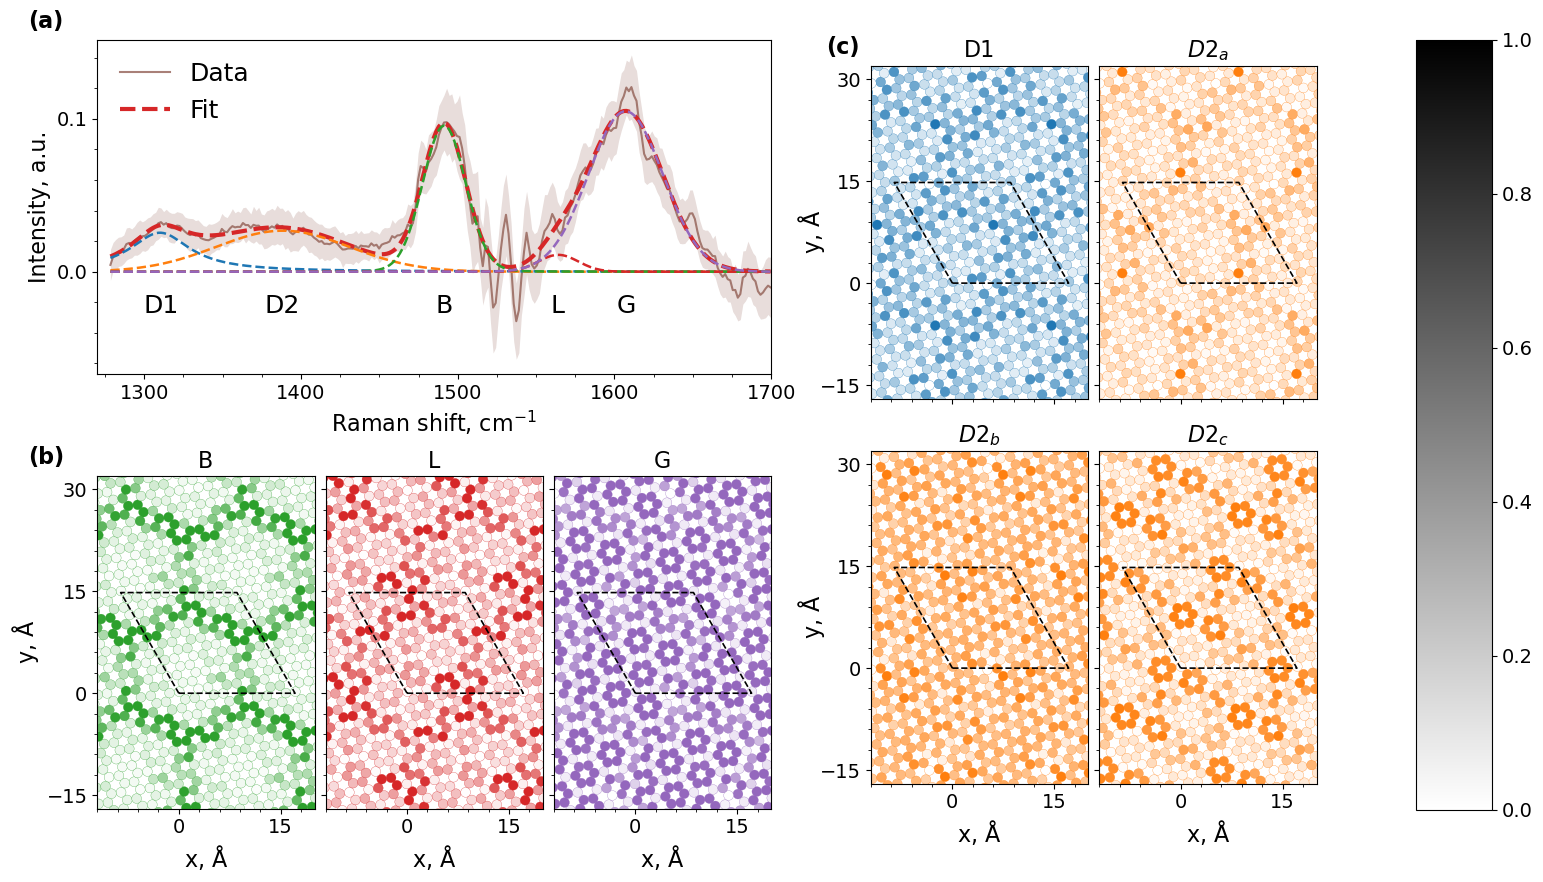

[1.31003038e+03 4.67611188e+01 1.87426618e+00 9.99997027e-01
 1.38831807e+03 1.00000000e+02 2.85679873e+00 1.32750023e-13
 1.49131813e+03 3.24085309e+01 3.34119197e+00 3.17569249e-02
 1.56418018e+03 3.00000000e+01 3.52338165e-01 3.34259074e-18
 1.60709078e+03 5.59656474e+01 6.25517701e+00 2.50442642e-30]


In [8]:
xlim = (-12, 20)
ylim = (-17, 32)
marker_size_maps = 50

inner_w = 0.05

W_left  = 3.0 + 2.0*inner_w   # 3 cols => 2 gaps
W_right = 2.0 + 1.0*inner_w   # 2 cols => 1 gap

fig = plt.figure(figsize=(18, 10))

outer = fig.add_gridspec(
    2, 3,
    width_ratios=[W_left, W_right, 0.35],
    wspace=0.25,                           # gap between blocks (spectrum vs D1)
    hspace=0.25
)

gs_left  = outer[:, 0].subgridspec(2, 3, wspace=inner_w, hspace=0.25+inner_w)
gs_right = outer[:, 1].subgridspec(2, 2, wspace=inner_w, hspace=0)

ax_spec = fig.add_subplot(gs_left[0, :])

ax_B = fig.add_subplot(gs_left[1, 0])
ax_L = fig.add_subplot(gs_left[1, 1], sharex=ax_B, sharey=ax_B)
ax_G = fig.add_subplot(gs_left[1, 2], sharex=ax_B, sharey=ax_B)

# ax_D1 = fig.add_subplot(gs_right[0, 0], sharex=ax_B, sharey=ax_B)
# ax_D2 = fig.add_subplot(gs_right[0, 1], sharex=ax_B, sharey=ax_B)
# ax_D3 = fig.add_subplot(gs_right[1, 0], sharex=ax_B, sharey=ax_B)
# ax_D4 = fig.add_subplot(gs_right[1, 1], sharex=ax_B, sharey=ax_B)

ax_D1 = fig.add_subplot(gs_right[0, 0])
ax_D2 = fig.add_subplot(gs_right[0, 1])
ax_D3 = fig.add_subplot(gs_right[1, 0])
ax_D4 = fig.add_subplot(gs_right[1, 1])

label_fontsize = 16
label_fontweight = 'bold'

label_coords = [-0.05, 1.02]

ax_spec.text(label_coords[0], label_coords[1], '(a)', transform=ax_spec.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_B.text(label_coords[0]*3, label_coords[1], '(b)', transform=ax_B.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_D1.text(label_coords[0], label_coords[1], '(c)', transform=ax_D1.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)

cax = fig.add_subplot(outer[:, 2])
# --- Top-left: Exp. data + fit
popt = plot_zoomed_region_panel_fit(
    ax_spec, ds,
    x_min=1270.0, x_max=1700.0,
    rough_centers=(1320, 1375, 1485, 1556, 1606),
    peak_labels=("D1", "D2", "B", "L", "G"),
    show_std_band=True,
    data_color="tab:brown"
)

# --- Bottom-left: B / L / G maps
plot_peak_map(ax_B, all_xy, all_B, cell_poly, "B",
              top_color="tab:green", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_L, all_xy, all_L, cell_poly, "L",
              top_color="tab:red", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

plot_peak_map(ax_G, all_xy, all_G, cell_poly, "G",
              top_color="tab:purple", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

# --- Right block: D1 - D4 maps
sc_bg = plot_peak_map(ax_D1, all_xy, all_D1, cell_poly, "D1",
                      top_color="tab:blue", marker_size=marker_size_maps,
                      vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=True)

plot_peak_map(ax_D2, all_xy, all_D2, cell_poly, "$D2_a$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=False)

plot_peak_map(ax_D3, all_xy, all_D3, cell_poly, "$D2_b$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_D4, all_xy, all_D4, cell_poly, "$D2_c$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=False)

ax_D1.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)
ax_D3.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)

for ax in (ax_B, ax_L, ax_G, ax_D1, ax_D2, ax_D3, ax_D4):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

# Shared grayscale colorbar
cb = fig.colorbar(sc_bg, cax=cax)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# plt.savefig('multipanel.svg',dpi=300)
plt.show()

print(popt)

/tmp/ipykernel_7485/3282006105.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


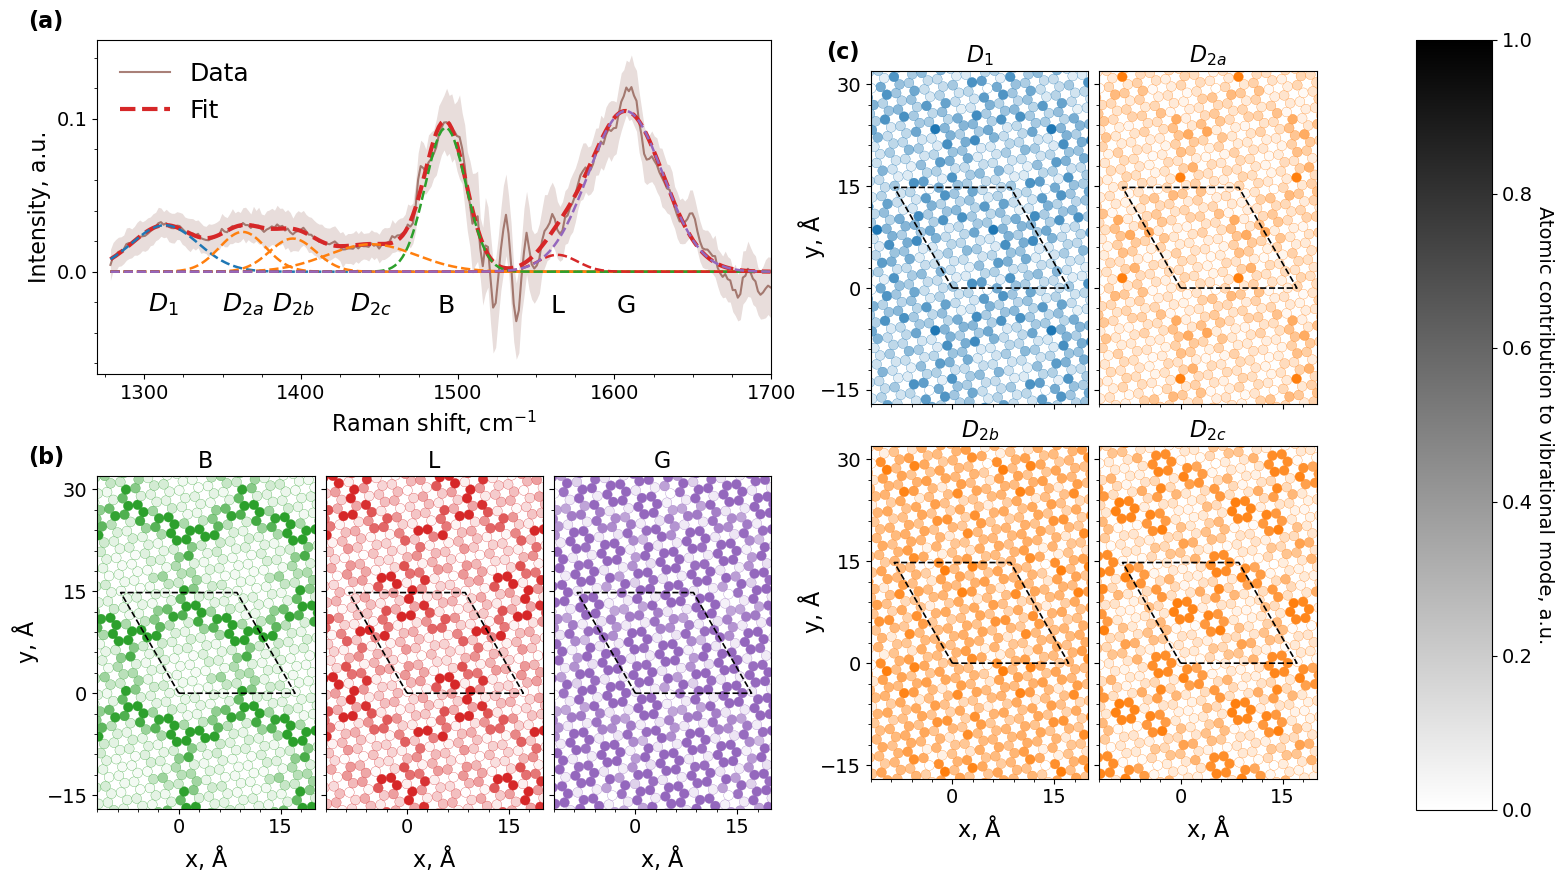

[1.31313139e+03 5.04147469e+01 1.63134059e+00 1.50694248e-16
 1.36273157e+03 3.49896927e+01 9.71141255e-01 4.63753459e-21
 1.39467326e+03 3.48590410e+01 8.04990307e-01 9.58483887e-22
 1.44500000e+03 6.70994537e+01 1.28427753e+00 1.14726367e-36
 1.49228371e+03 3.03203270e+01 3.04044091e+00 4.60091695e-42
 1.56361735e+03 3.00000000e+01 3.52678270e-01 2.29204416e-26
 1.60703221e+03 5.61857223e+01 6.28937056e+00 4.09087111e-41]


In [9]:
xlim = (-12, 20)
ylim = (-17, 32)
marker_size_maps = 50

inner_w = 0.05

W_left  = 3.0 + 2.0*inner_w   # 3 cols => 2 gaps
W_right = 2.0 + 1.0*inner_w   # 2 cols => 1 gap

fig = plt.figure(figsize=(18, 10))

outer = fig.add_gridspec(
    2, 3,
    width_ratios=[W_left, W_right, 0.35],
    wspace=0.25,                           # gap between blocks (spectrum vs D1)
    hspace=0.25
)

gs_left  = outer[:, 0].subgridspec(2, 3, wspace=inner_w, hspace=0.25+inner_w)
gs_right = outer[:, 1].subgridspec(2, 2, wspace=inner_w, hspace=0-inner_w)

ax_spec = fig.add_subplot(gs_left[0, :])

ax_B = fig.add_subplot(gs_left[1, 0])
ax_L = fig.add_subplot(gs_left[1, 1], sharex=ax_B, sharey=ax_B)
ax_G = fig.add_subplot(gs_left[1, 2], sharex=ax_B, sharey=ax_B)

# ax_D1 = fig.add_subplot(gs_right[0, 0], sharex=ax_B, sharey=ax_B)
# ax_D2 = fig.add_subplot(gs_right[0, 1], sharex=ax_B, sharey=ax_B)
# ax_D3 = fig.add_subplot(gs_right[1, 0], sharex=ax_B, sharey=ax_B)
# ax_D4 = fig.add_subplot(gs_right[1, 1], sharex=ax_B, sharey=ax_B)

ax_D1 = fig.add_subplot(gs_right[0, 0])
ax_D2 = fig.add_subplot(gs_right[0, 1])
ax_D3 = fig.add_subplot(gs_right[1, 0])
ax_D4 = fig.add_subplot(gs_right[1, 1])

label_fontsize = 16
label_fontweight = 'bold'

label_coords = [-0.05, 1.02]

ax_spec.text(label_coords[0], label_coords[1], '(a)', transform=ax_spec.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_B.text(label_coords[0]*3, label_coords[1], '(b)', transform=ax_B.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_D1.text(label_coords[0], label_coords[1], '(c)', transform=ax_D1.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)

cax = fig.add_subplot(outer[:, 2])
# --- Top-left: Exp. data + fit
peak_labels=("$D_1$", r"$D_{2a}$", r"$D_{2b}$", r"$D_{2c}$", "B", "L", "G")
popt = plot_zoomed_region_panel_fit(
    ax_spec, ds,
    x_min=1270.0, x_max=1700.0,
    rough_centers=(1320, 1375, 1400, 1425, 1485, 1556, 1606),
    peak_labels=peak_labels,
    show_std_band=True,
    data_color="tab:brown"
)

# --- Bottom-left: B / L / G maps
plot_peak_map(ax_B, all_xy, all_B, cell_poly, "B",
              top_color="tab:green", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_L, all_xy, all_L, cell_poly, "L",
              top_color="tab:red", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

plot_peak_map(ax_G, all_xy, all_G, cell_poly, "G",
              top_color="tab:purple", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

# --- Right block: D1 - D4 maps
sc_bg = plot_peak_map(ax_D1, all_xy, all_D1, cell_poly, "$D_1$",
                      top_color="tab:blue", marker_size=marker_size_maps,
                      vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=True)

plot_peak_map(ax_D2, all_xy, all_D2, cell_poly, r"$D_{2a}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=False)

plot_peak_map(ax_D3, all_xy, all_D3, cell_poly, r"$D_{2b}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_D4, all_xy, all_D4, cell_poly, r"$D_{2c}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=False)

ax_D1.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)
ax_D3.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)

for ax in (ax_B, ax_L, ax_G, ax_D1, ax_D2, ax_D3, ax_D4):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

# Shared grayscale colorbar
cb = fig.colorbar(sc_bg, cax=cax, )
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cb.set_label("Atomic contribution to vibrational mode, a.u.", fontsize=14, rotation=-90, labelpad=15)

plt.tight_layout()

# plt.savefig('multipanel_D2abc.svg',dpi=300)
# plt.savefig('multipanel_D2abc.png',dpi=300)
# plt.savefig('multipanel_D2abc.pdf',dpi=300)
plt.show()

print(popt)

In [10]:
for i in range(len(popt)//4):
    c, w, A, r = popt[4*i:4*i+4]
    print(f"Peak {peak_labels[i]}: Center = {c:.2f}, FWHM = {w:.2f}, Area = {A:.2f}, Lorentz fraction = {r:.4f}\n")

Peak $D_1$: Center = 1313.13, FWHM = 50.41, Area = 1.63, Lorentz fraction = 0.0000

Peak $D_{2a}$: Center = 1362.73, FWHM = 34.99, Area = 0.97, Lorentz fraction = 0.0000

Peak $D_{2b}$: Center = 1394.67, FWHM = 34.86, Area = 0.80, Lorentz fraction = 0.0000

Peak $D_{2c}$: Center = 1445.00, FWHM = 67.10, Area = 1.28, Lorentz fraction = 0.0000

Peak B: Center = 1492.28, FWHM = 30.32, Area = 3.04, Lorentz fraction = 0.0000

Peak L: Center = 1563.62, FWHM = 30.00, Area = 0.35, Lorentz fraction = 0.0000

Peak G: Center = 1607.03, FWHM = 56.19, Area = 6.29, Lorentz fraction = 0.0000



# Plot with aligned frames

/tmp/ipykernel_7485/715892046.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


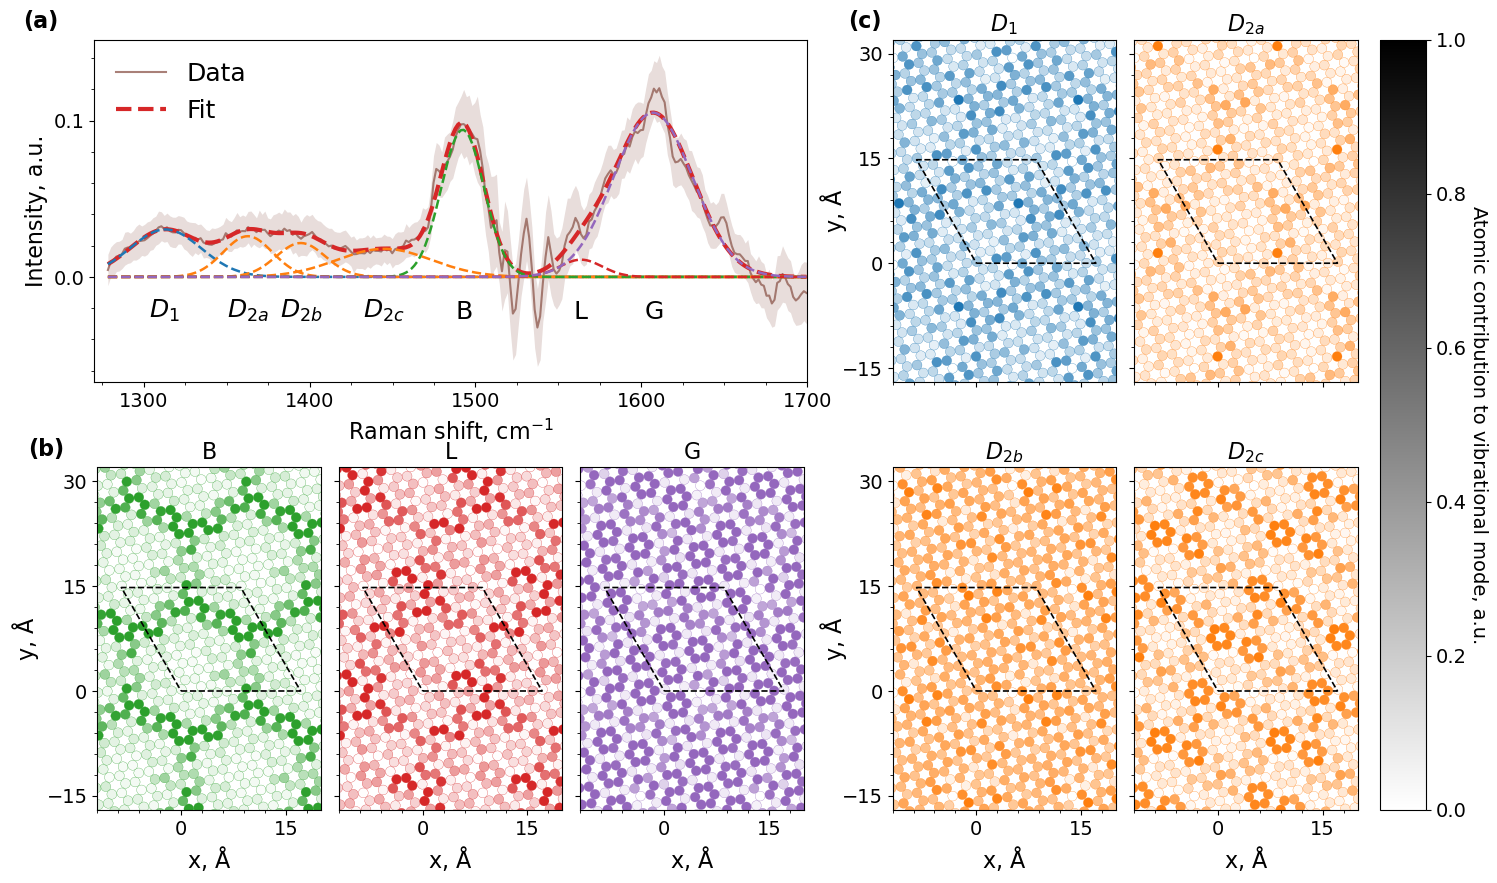

[1.31313139e+03 5.04147469e+01 1.63134059e+00 1.50694248e-16
 1.36273157e+03 3.49896927e+01 9.71141255e-01 4.63753459e-21
 1.39467326e+03 3.48590410e+01 8.04990307e-01 9.58483887e-22
 1.44500000e+03 6.70994537e+01 1.28427753e+00 1.14726367e-36
 1.49228371e+03 3.03203270e+01 3.04044091e+00 4.60091695e-42
 1.56361735e+03 3.00000000e+01 3.52678270e-01 2.29204416e-26
 1.60703221e+03 5.61857223e+01 6.28937056e+00 4.09087111e-41]


In [14]:
xlim = (-12, 20)
ylim = (-17, 32)
marker_size_maps = 50

inner_w = 0.05

W_left  = 3.0 + 2.0*inner_w   # 3 cols => 2 gaps
W_right = 2.0 + 1.0*inner_w   # 2 cols => 1 gap

fig = plt.figure(figsize=(18, 10))

outer = fig.add_gridspec(
    2, 3,
    width_ratios=[W_left, W_right, 0.20],
    wspace=0.2,                           # gap between blocks (spectrum vs D1)
    hspace=0.25
)

gs_left  = outer[:, 0].subgridspec(2, 3, wspace=inner_w, hspace=0.25)
gs_right = outer[:, 1].subgridspec(2, 2, wspace=inner_w, hspace=0.25)

ax_spec = fig.add_subplot(gs_left[0, :])

ax_B = fig.add_subplot(gs_left[1, 0])
ax_L = fig.add_subplot(gs_left[1, 1], sharex=ax_B, sharey=ax_B)
ax_G = fig.add_subplot(gs_left[1, 2], sharex=ax_B, sharey=ax_B)

# ax_D1 = fig.add_subplot(gs_right[0, 0], sharex=ax_B, sharey=ax_B)
# ax_D2 = fig.add_subplot(gs_right[0, 1], sharex=ax_B, sharey=ax_B)
# ax_D3 = fig.add_subplot(gs_right[1, 0], sharex=ax_B, sharey=ax_B)
# ax_D4 = fig.add_subplot(gs_right[1, 1], sharex=ax_B, sharey=ax_B)

ax_D1 = fig.add_subplot(gs_right[0, 0])
ax_D2 = fig.add_subplot(gs_right[0, 1])
ax_D3 = fig.add_subplot(gs_right[1, 0])
ax_D4 = fig.add_subplot(gs_right[1, 1])

label_fontsize = 16
label_fontweight = 'bold'

label_coords = [-0.05, 1.02]

ax_spec.text(label_coords[0], label_coords[1], '(a)', transform=ax_spec.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_B.text(label_coords[0]*3, label_coords[1], '(b)', transform=ax_B.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)
ax_D1.text(label_coords[0], label_coords[1], '(c)', transform=ax_D1.transAxes, fontsize=label_fontsize, fontweight=label_fontweight, va='bottom', ha='right', clip_on=False)

cax = fig.add_subplot(outer[:, 2])
# --- Top-left: Exp. data + fit
peak_labels=("$D_1$", r"$D_{2a}$", r"$D_{2b}$", r"$D_{2c}$", "B", "L", "G")
popt = plot_zoomed_region_panel_fit(
    ax_spec, ds,
    x_min=1270.0, x_max=1700.0,
    rough_centers=(1320, 1375, 1400, 1425, 1485, 1556, 1606),
    peak_labels=peak_labels,
    show_std_band=True,
    data_color="tab:brown"
)

# --- Bottom-left: B / L / G maps
plot_peak_map(ax_B, all_xy, all_B, cell_poly, "B",
              top_color="tab:green", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_L, all_xy, all_L, cell_poly, "L",
              top_color="tab:red", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

plot_peak_map(ax_G, all_xy, all_G, cell_poly, "G",
              top_color="tab:purple", marker_size=marker_size_maps,
              vmin=0.0, vmax=0.5, show_xlabel=True, show_ylabel=False)

# --- Right block: D1 - D4 maps
sc_bg = plot_peak_map(ax_D1, all_xy, all_D1, cell_poly, "$D_1$",
                      top_color="tab:blue", marker_size=marker_size_maps,
                      vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=True)

plot_peak_map(ax_D2, all_xy, all_D2, cell_poly, r"$D_{2a}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=False, show_ylabel=False)

plot_peak_map(ax_D3, all_xy, all_D3, cell_poly, r"$D_{2b}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=True)

plot_peak_map(ax_D4, all_xy, all_D4, cell_poly, r"$D_{2c}$",
              top_color="tab:orange", marker_size=marker_size_maps,
              vmin=0.0, vmax=1.0, show_xlabel=True, show_ylabel=False)

ax_D1.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)
ax_D3.set_ylabel(r"y, $\rm \AA{}$", labelpad=-5)

for ax in (ax_B, ax_L, ax_G, ax_D1, ax_D2, ax_D3, ax_D4):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")

# Shared grayscale colorbar
pos = cax.get_position()
cax.set_position([
    pos.x0 - 0.035,   # move left (increase magnitude carefully)
    pos.y0,
    pos.width,
    pos.height
])
cb = fig.colorbar(sc_bg, cax=cax)
cb.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cb.set_label("Atomic contribution to vibrational mode, a.u.", fontsize=14, rotation=-90, labelpad=15)

plt.tight_layout()

plt.savefig('multipanel_D_1_D_2abc.svg',dpi=300)
plt.savefig('multipanel_D_1_D_2abc.png',dpi=300)
plt.savefig('multipanel_D_1_D_2abc_lowres.png',dpi=96)
plt.savefig('multipanel_D_1_D_2abc.pdf',dpi=300)
plt.show()

print(popt)